In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

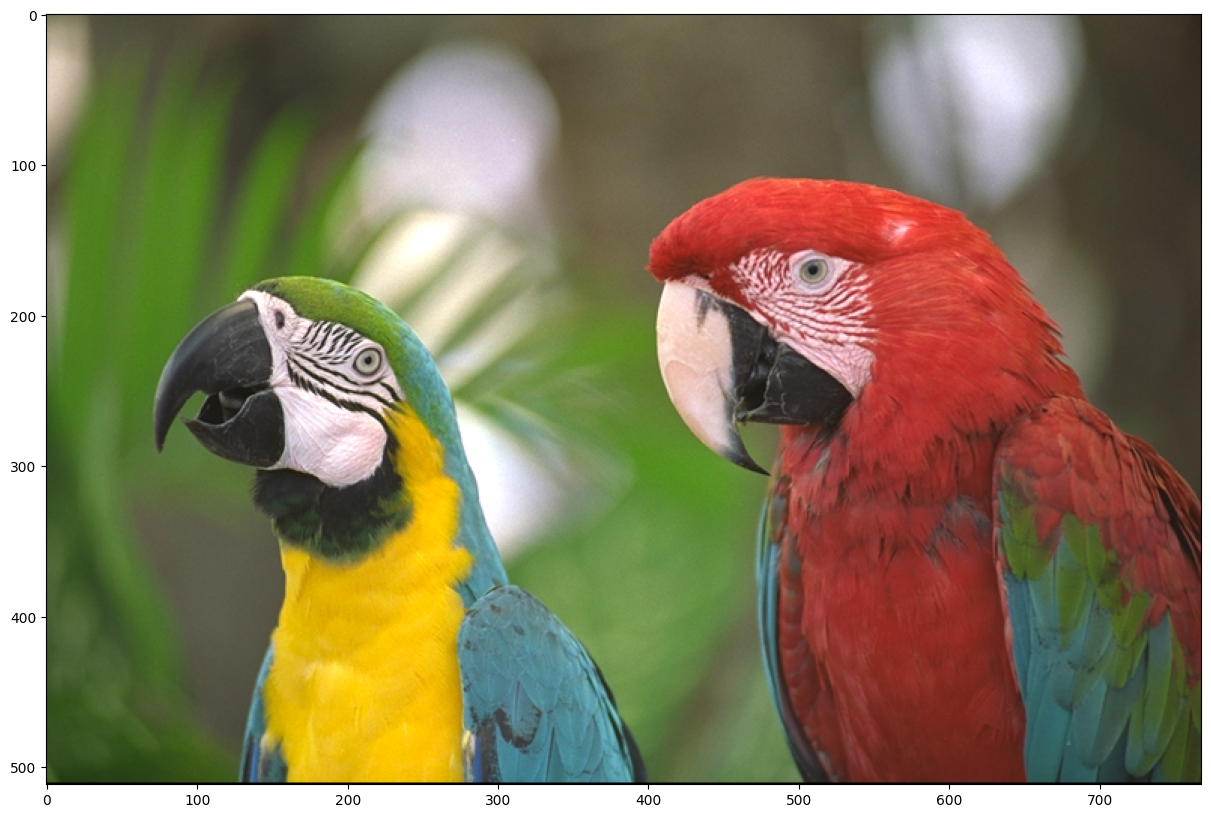

In [3]:
# Load image
img = cv2.imread('/content/drive/MyDrive/Something_for_labs/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

In [4]:
# Black, dark gray, light gray, white
palette = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

In [5]:
# Using the colour pallette, let's quantize the original image.

# Cast the image to float
img = img.astype(float)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]

        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.linalg.norm(palette - pixel, axis=1)
        new_pixel =  palette[np.argmin(distances)]

        # Apply quantization
        quantized[r, c, :] = new_pixel

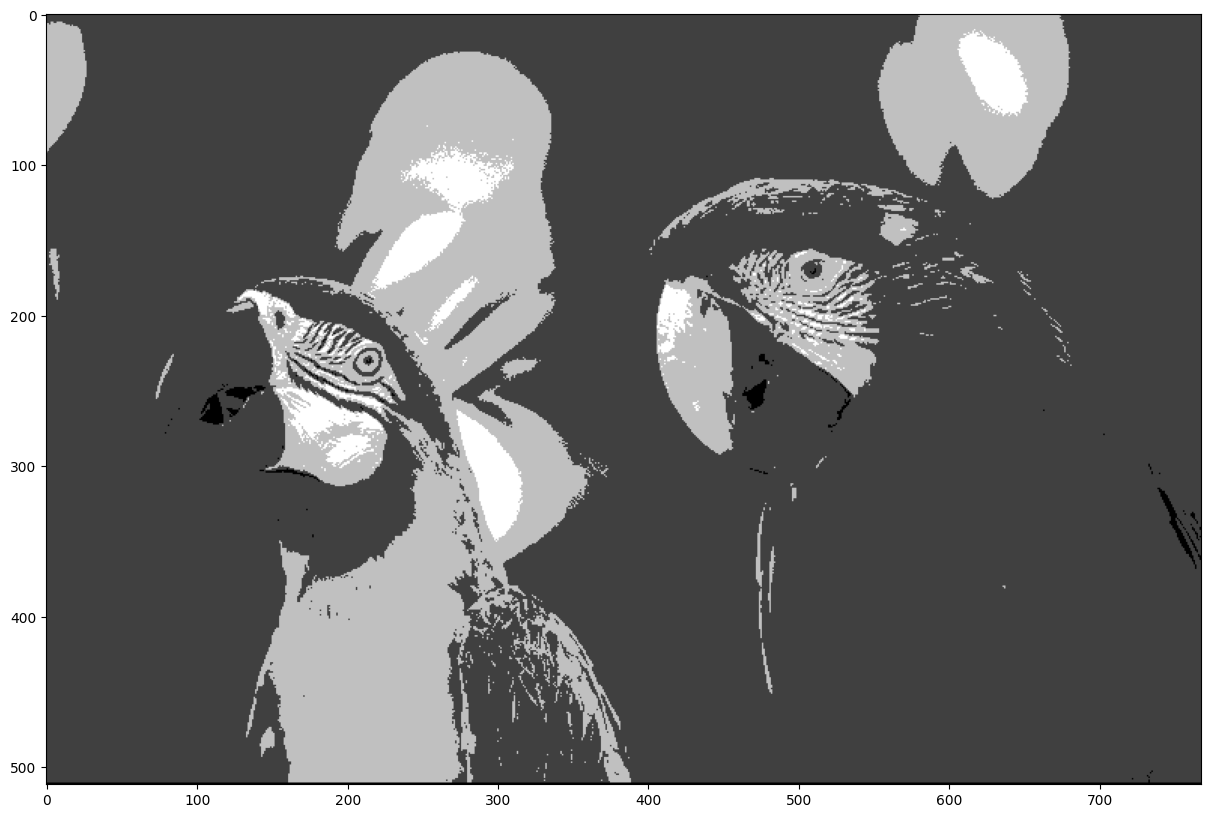

In [7]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized.astype(np.uint8))

In [8]:
# Compute average quantization error
avg_quant_error = np.mean((img - quantized)**2)
print(f"avg_quant_error: {avg_quant_error}")

avg_quant_error: 2140.2978049384224


In [11]:
# Floyd-Steinberg Dithering

# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        distances = np.linalg.norm(palette - pixel, axis=1)

        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        new_pixel = palette[np.argmin(distances)]

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        #       x     7/16
        # 3/16  5/16  1/16
        img_tmp[r, c+1, :] += quant_error * 7/16
        img_tmp[r+1, c-1, :] += quant_error * 3/16
        img_tmp[r+1, c, :] += quant_error * 5/16
        img_tmp[r+1, c+1, :] += quant_error * 1/16

        dithering[r, c, :] = new_pixel

# Обмежуємо значення
dithering = np.clip(dithering, 0, 255)


(<Axes: >, <matplotlib.image.AxesImage at 0x7db823565e20>)

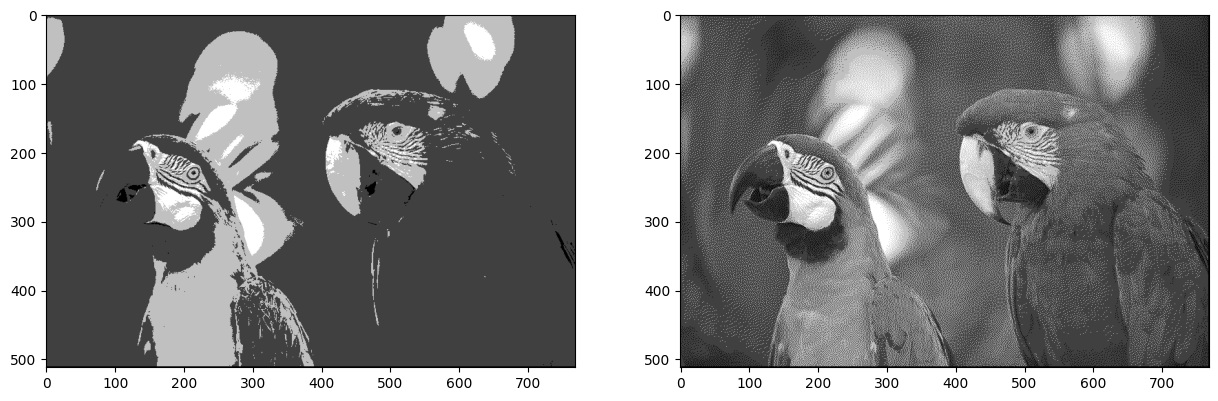

In [12]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))
plt.subplot(122), plt.imshow(dithering.astype(np.uint8))

In [13]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean((img - dithering)**2)
print(f"avg_dith_error: {avg_dith_error}")

avg_dith_error: 3303.1499099731445


In [14]:
from sklearn.cluster import KMeans
pixels = np.reshape(img, (-1, 3))
kmeans = KMeans(n_clusters=16, n_init=10, random_state=42).fit(pixels)
palette = kmeans.cluster_centers_
print("Optimal palette shape:", palette.shape)

Optimal palette shape: (16, 3)
